In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data = pd.read_excel(r"C:\Users\test\Downloads\Flight_Price_resources/Data_Train.xlsx")

In [3]:
train_data.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
train_data.tail(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
train_data.isnull().sum()  #showing values that have null values

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
train_data[train_data['Total_Stops'].isnull()] #showimg the null value

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [8]:
train_data[train_data['Route'].isnull()] #showimg the null value

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [9]:
train_data.dropna(inplace=True) #dropping the null value

In [10]:
train_data[train_data['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [11]:
train_data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [12]:
# 1st problem statements: Lets perform pre process and extract derived attributes from "Date_of _journey" 

In [13]:
data = train_data.copy()

In [14]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [15]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [16]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [17]:
#converting Date_of_journey,Dep_Time,Arrival_Time from object into datetime64[ns]/timestamp 

In [18]:
#define the function

In [19]:
def change_into_Datetime(col):
   data[col] = pd.to_datetime(data[col])

In [20]:
#leveraging the warning package

In [21]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [22]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [23]:
for feature in ['Dep_Time', 'Arrival_Time', 'Date_of_Journey']:
    change_into_Datetime(feature)

In [24]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [25]:
data["Journey_month"] = data['Date_of_Journey'].dt.month   #dt daytime attribute, extracting month,day and year

In [26]:
data["Journey_day"] =data['Date_of_Journey'].dt.day

In [27]:
data["Journey_year"] =data['Date_of_Journey'].dt.year

In [28]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-02 05:50:00,2026-02-02 13:15:00,7h 25m,2 stops,No info,7662,5,1,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9,2019


In [29]:
#Data cleaning preparing it for model building

In [30]:
#Problem statement: clean Dep_time & Arrival_Time and then extract derived attributes

In [31]:
#first we design a function arrival_time

In [32]:
def extract_hour_min(df , col):
    df[col+"_hour"]=df[col].dt.hour
    df[col+"_minute"]=df[col].dt.minute
    return df.head(3)

In [33]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_month', 'Journey_day',
       'Journey_year'],
      dtype='object')

In [34]:
extract_hour_min(data , "Dep_Time") #calling similar function with a different features Arrival_time

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-02 05:50:00,2026-02-02 13:15:00,7h 25m,2 stops,No info,7662,5,1,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9,2019,9,25


In [35]:
extract_hour_min(data , "Arrival_Time") #calling similar function with a different features Arrival_time

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-02 05:50:00,2026-02-02 13:15:00,7h 25m,2 stops,No info,7662,5,1,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9,2019,9,25,4,25


In [36]:
cols_to_drop =['Dep_Time', 'Arrival_Time']

data.drop(cols_to_drop ,axis=1 ,inplace=True) #drop colums

In [37]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,24,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,1,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,6,9,2019,9,25,4,25


In [38]:
data.shape

(10682, 16)

In [39]:
#Data Analysis #problem statement >> let ananlyse when will most of the flight take off

In [40]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute'],
      dtype='object')

In [41]:
#extract values by using dep_time feature by using if-elif-else

In [42]:
#define the funcion using on dep_time_hour to get morning, afternoon ,night

In [43]:
def flight_dep_time(x):

    if (x>4) and (x<=8):
        return "Early Morning"

    elif (x>8) and (x<=12):
        return "Morning"

    elif (x>12) and (x<=16):
        return "Afternoon"

    elif (x>16) and (x<=20):
        return "Evening"

    elif (x>20) and (x<=24):
        return "Night"

    else:
        return "Late Night"

In [44]:
# access a feature which is dep_time_hour and apply the function to whats defined

In [45]:
data['Dep_Time_hour'].apply(flight_dep_time)

0                Night
1        Early Morning
2              Morning
3              Evening
4            Afternoon
             ...      
10678          Evening
10679          Evening
10680    Early Morning
10681          Morning
10682          Morning
Name: Dep_Time_hour, Length: 10682, dtype: object

In [46]:
#finding the count of every shift

In [47]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts()

Dep_Time_hour
Early Morning    2880
Evening          2357
Morning          2209
Afternoon        1731
Night            1040
Late Night        465
Name: count, dtype: int64

In [48]:
# plot using

<Axes: xlabel='Dep_Time_hour'>

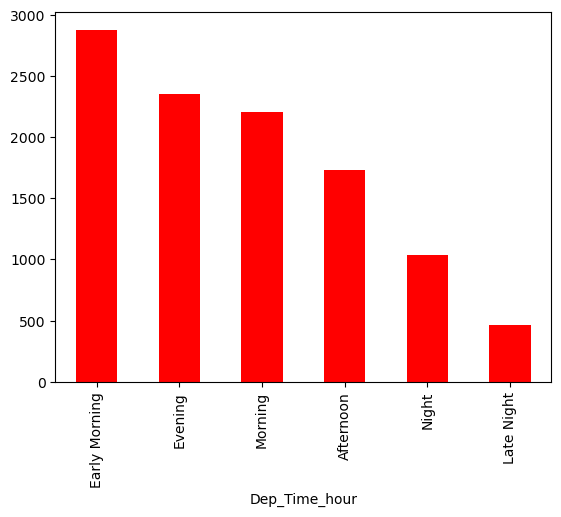

In [49]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind="bar" , color="red")

In [50]:
#making the chart more intaractive by going with plotly

In [51]:
#installing plotly and chart_studio

In [52]:
import plotly
import cufflinks as cf
from cufflinks.offline import go_offline #making chart more intactive with offline mode 
from plotly.offline import plot, iplot, init_notebook_mode, download_plotlyjs
init_notebook_mode(connected=True)
cf.go_offline()

<Axes: xlabel='Dep_Time_hour'>

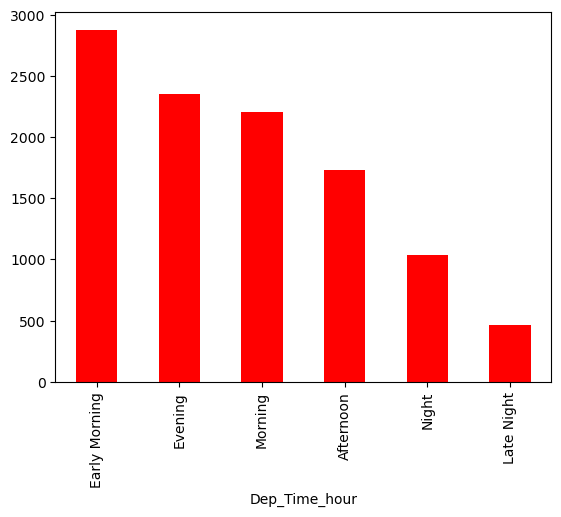

In [53]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind="bar" , color="red")

In [54]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,24,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,1,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,6,9,2019,9,25,4,25


In [55]:
#making the duration features ready for DA and Ml by converting it from string data to verctor

In [56]:
#designing a function that converts 19hr and 45min to 19hr:00min and 00hrs:45min

In [57]:
def preprocess_duration(x):
    if 'h' not in x:
        x = '0h' + ' ' + x
    elif 'm' not in x:
        x = x + ' ' + '0m' 

    return x

In [58]:
data['Duration'].apply(preprocess_duration)

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [59]:
# updating the duration

In [60]:
data['Duration'] = data['Duration'].apply(preprocess_duration)

In [61]:
data['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [62]:
#extracting features like duration hour, duration minutes

In [63]:
data['Duration'][0]

'2h 50m'

In [64]:
#sliping strings considering space as a separetor

In [65]:
'2h 50m'.split(' ')

['2h', '50m']

In [66]:
#accessing data of 0 index

In [67]:
'2h 50m'.split(' ')[0]

'2h'

In [68]:
'2h 50m'.split(' ')[0][0:-1]

'2'

In [69]:
#checking if its string in nature

In [70]:
type('2h 50m'.split(' ')[0][0:-1]) 

str

In [71]:
#convert to integer

In [72]:
int('2h 50m'.split(' ')[0][0:-1])

2

In [73]:
int('2h 50m'.split(' ')[1][0:-1])

50

In [74]:
#using lambda for annon function

In [75]:
data['Duration_hour'] = data['Duration'].apply(lambda x : int(x.split(' ')[0][0:-1]))

In [76]:
data['Duration_mins'] = data['Duration'].apply(lambda x : int(x.split(' ')[1][0:-1]))

In [77]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,24,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,1,2019,5,50,13,15,7,25


In [78]:
#problem statement analyse whether duation impacts on price or not

In [79]:
data['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [80]:
# to do arithimetic function on a string you need eval function

In [81]:
eval('2*60')

120

In [82]:
data['Duration'].str.replace('h' , "*60").str.replace(' ' , '+').str.replace('m' ," *1")

0        2*60+50 *1
1        7*60+25 *1
2        19*60+0 *1
3        5*60+25 *1
4        4*60+45 *1
            ...    
10678    2*60+30 *1
10679    2*60+35 *1
10680     3*60+0 *1
10681    2*60+40 *1
10682    8*60+20 *1
Name: Duration, Length: 10682, dtype: object

In [83]:
data['Duration'].str.replace('h' , "*60").str.replace(' ' , '+').str.replace('m' ," *1").apply(eval)

0         170
1         445
2        1140
3         325
4         285
         ... 
10678     150
10679     155
10680     180
10681     160
10682     500
Name: Duration, Length: 10682, dtype: int64

In [84]:
# store as duration_total_min

In [85]:
data['Duration_total_min'] = data['Duration'].str.replace('h' , "*60").str.replace(' ' , '+').str.replace('m' ," *1").apply(eval)

In [86]:
data['Duration_total_min']

0         170
1         445
2        1140
3         325
4         285
         ... 
10678     150
10679     155
10680     180
10681     160
10682     500
Name: Duration_total_min, Length: 10682, dtype: int64

In [87]:
#now analyzing if duration time is gonna impact price using scatterplot or regresion plot

In [88]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Duration_total_min'],
      dtype='object')

<Axes: xlabel='Duration_total_min', ylabel='Price'>

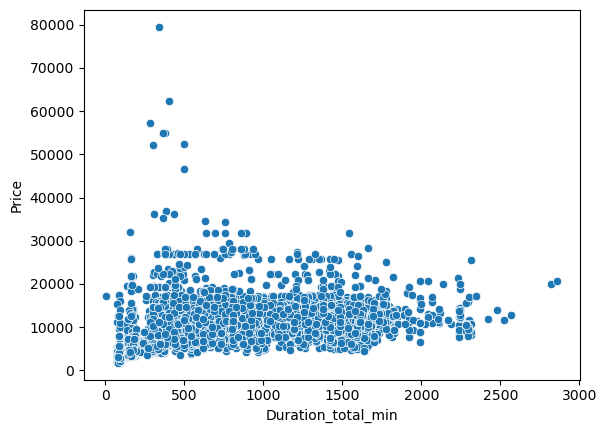

In [89]:
sns.scatterplot(x="Duration_total_min" , y="Price" , data=data)

In [90]:
#using regression plot lmplot

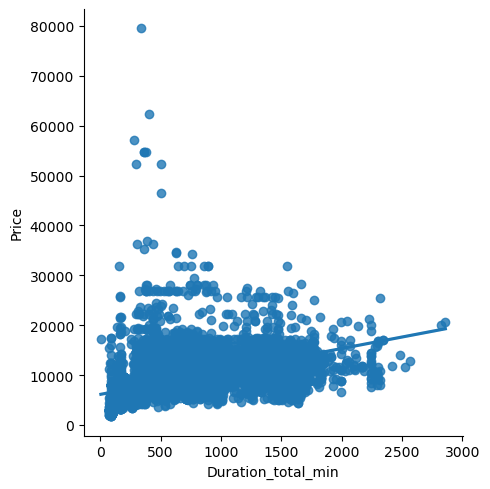

In [91]:
sns.lmplot(x="Duration_total_min" , y="Price" , data=data)

In [92]:
# create for all flight which as 1,2 or 3 stops using the hue paramiters

<Axes: xlabel='Duration_total_min', ylabel='Price'>

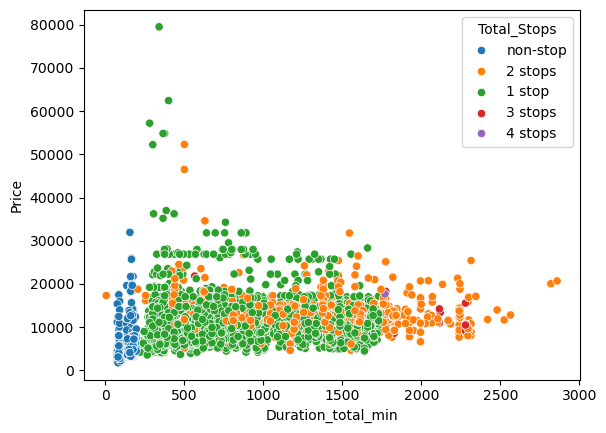

In [93]:
sns.scatterplot(x="Duration_total_min" , y="Price" , hue="Total_Stops" , data=data)

In [94]:
#PS on which route jet airway is extremely used , airline vs price analysis

In [95]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Duration_total_min'],
      dtype='object')

In [96]:
data[data['Airline']=='Jet Airways'].groupby('Route').count()

,Airline,Date_of_Journey,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min
Route,,,,,,,,,,,,,,,,,,
BLR → BDQ → DEL,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
BLR → BOM → DEL,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385
BLR → BOM → JDH → DEL,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
BLR → DEL,382,382,382,382,382,382,382,382,382,382,382,382,382,382,382,382,382,382
BLR → MAA → DEL,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
BOM → BDQ → DEL → HYD,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
BOM → DED → DEL → HYD,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BOM → DEL → HYD,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
BOM → HYD,207,207,207,207,207,207,207,207,207,207,207,207,207,207,207,207,207,207


In [97]:
#call a function instead of count call size fuction

In [98]:
data[data['Airline']=='Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
DEL → JAI → BOM → COK    207
BOM → HYD                207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
BOM → IDR → DEL → HYD      1
BOM → VNS → DEL → HYD      1
BOM → DED → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → UDR → DEL → HYD      1
DEL → CCU → BOM → COK      1
dtype: int64

In [99]:
 #airline vs price analysis using boxplot

In [100]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Duration_total_min'],
      dtype='object')

<Axes: xlabel='Airline', ylabel='Price'>

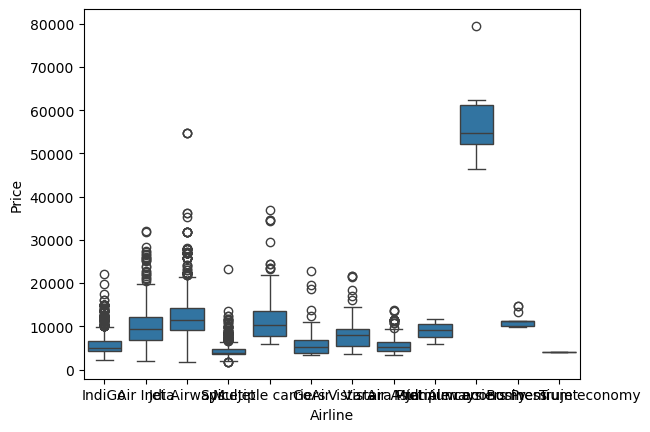

In [101]:
sns.boxplot(y='Price' , x='Airline' , data=data)

In [102]:
#fixing the overlapping issuses with the airline name by using the rotate function plt.xticks

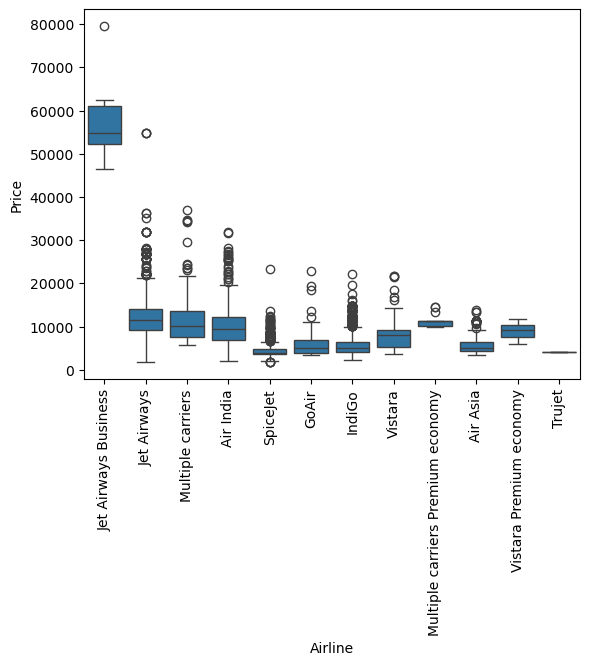

In [103]:
sns.boxplot(y='Price' , x='Airline' , data=data.sort_values('Price' , ascending=False))
plt.xticks(rotation="vertical")
plt.show()

In [104]:
#feature engineering by applying one-hot on data

In [105]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,Journey_day,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,24,2019,22,20,1,10,2,50,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,1,2019,5,50,13,15,7,25,445


In [106]:
#converting source , destination, airline string data to vector or numbers

In [107]:
#creating features for your source , destination, airline which as 11sub category so we have 11 features to explain to the ml

In [108]:
#apply feature encoding cat_col we will store all category features which as data type as object

In [109]:
#apply feature encoding numerical_col we will store all numerical features which as data type as object

In [110]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Duration_total_min'],
      dtype='object')

In [111]:
[col for col in data.columns if data[col].dtype=="object"]

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [112]:
[col for col in data.columns if data[col].dtype!="object"] #what if the datatype is not = object

['Date_of_Journey',
 'Price',
 'Journey_month',
 'Journey_day',
 'Journey_year',
 'Dep_Time_hour',
 'Dep_Time_minute',
 'Arrival_Time_hour',
 'Arrival_Time_minute',
 'Duration_hour',
 'Duration_mins',
 'Duration_total_min']

In [113]:
cat_col =[col for col in data.columns if data[col].dtype=="object"] #rename

In [114]:
num_col = [col for col in data.columns if data[col].dtype!="object"]

In [115]:
cat_col

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [116]:
data['Source']

0        Banglore
1         Kolkata
2           Delhi
3         Kolkata
4        Banglore
           ...   
10678     Kolkata
10679     Kolkata
10680    Banglore
10681    Banglore
10682       Delhi
Name: Source, Length: 10682, dtype: object

In [117]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [118]:
#apply one hot from scratch for future encoding

In [119]:
data['Source'].apply(lambda x : 1 if x == 'Banglore' else 0)

0        1
1        0
2        0
3        0
4        1
        ..
10678    0
10679    0
10680    1
10681    1
10682    0
Name: Source, Length: 10682, dtype: int64

In [120]:
#applying to all source sub category by concatinatin it

In [121]:
for sub_category in data['Source'].unique():
  data['Source_'+sub_category] =  data['Source'].apply(lambda x : 1 if x == sub_category else 0)

In [122]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,13,15,7,25,445,0,1,0,0,0


In [123]:
#what weve done is applied one hot future encoding from scratch

In [124]:
#now doing future encoding on airline

In [125]:
data['Airline'].nunique()

12

In [126]:
#performing target guided rncoding and performing manual encoding on data

In [127]:
data.groupby(['Airline'])

In [128]:
#getting the average price for each of the airline

In [129]:
data.groupby(['Airline'])['Price'].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4338.284841
Air Asia                              5590.260188
IndiGo                                5673.682903
GoAir                                 5861.056701
Vistara                               7796.348643
Vistara Premium economy               8962.333333
Air India                             9612.427756
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11643.923357
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [130]:
airlines = data.groupby(['Airline'])['Price'].mean().sort_values().index

In [131]:
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [132]:
#converting array to a dictionary for the airline

In [133]:
dict_airlines={key:index for index , key in enumerate(airlines, 0)}

In [134]:
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [135]:
data['Airline'] = data['Airline'].map(dict_airlines)

In [136]:
data['Airline']

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10682, dtype: int64

In [137]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,13,15,7,25,445,0,1,0,0,0


In [138]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [139]:
#add a replace operation to add both delhi and new delhi together 

In [140]:
data['Destination'].replace('New Delhi' , 'Delhi' , inplace=True)

In [141]:
data['Destination'].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [142]:
dest = data.groupby(['Destination'])['Price'].mean().sort_values().index

In [143]:
dest

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='object', name='Destination')

In [144]:
#coverting array into a dictionary

In [145]:
dict_dest ={key:index for index , key in enumerate(dest, 0)}

In [146]:
dict_dest

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [147]:
#map the dictionary

In [148]:
data['Destination'] = data['Destination'].map(dict_dest)

In [149]:
data['Destination']

0        2
1        3
2        4
3        3
4        2
        ..
10678    3
10679    3
10680    2
10681    2
10682    4
Name: Destination, Length: 10682, dtype: int64

In [150]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,6,...,4,25,19,0,1140,0,0,1,0,0


In [151]:
#ps perform manual encoding on data, remove unnecessary features

In [152]:
data['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [153]:
# use label encoding when dealing with ordinal data using sklean

In [154]:
stop = {'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}

In [155]:
data['Total_Stops'] = data['Total_Stops'].map(stop)

In [156]:
data['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [157]:
#removing unnecessary features

In [158]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,3,...,1,10,2,50,170,1,0,0,0,0


In [159]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_month',
       'Journey_day', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Duration_total_min', 'Source_Banglore',
       'Source_Kolkata', 'Source_Delhi', 'Source_Chennai', 'Source_Mumbai'],
      dtype='object')

In [160]:
data['Additional_Info'].value_counts()/len(data)*100

Additional_Info
No info                         78.112713
In-flight meal not included     18.554578
No check-in baggage included     2.995694
1 Long layover                   0.177869
Change airports                  0.065531
Business class                   0.037446
No Info                          0.028085
1 Short layover                  0.009362
Red-eye flight                   0.009362
2 Long layover                   0.009362
Name: count, dtype: float64

In [161]:
data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_month,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Duration_total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,3,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,5,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,6,...,4,25,19,0,1140,0,0,1,0,0
3,3,2019-05-12,Kolkata,3,CCU → NAG → BLR,5h 25m,1,No info,6218,5,...,23,30,5,25,325,0,1,0,0,0


In [162]:
#drop route and duration hour and min from columns

In [163]:
data.drop(columns=['Date_of_Journey' , 'Additional_Info' , 'Duration_total_min' , 'Source' , 'Journey_year'] , axis=1 , inplace=True)

In [164]:
data.columns

Index(['Airline', 'Destination', 'Route', 'Duration', 'Total_Stops', 'Price',
       'Journey_month', 'Journey_day', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_mins', 'Source_Banglore', 'Source_Kolkata', 'Source_Delhi',
       'Source_Chennai', 'Source_Mumbai'],
      dtype='object')

In [165]:
data.drop(columns=['Route' , 'Duration'] , axis=1 , inplace=True)

In [166]:
data.head(3)

,Airline,Destination,Total_Stops,Price,Journey_month,Journey_day,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,3,24,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,5,1,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,6,9,9,25,4,25,19,0,0,0,1,0,0


In [167]:
#handling outlier in data and performing outlier detetion  / extream low and high so we can perform machine learning

In [168]:
#first way is to perform data visualization to know the oulier using box plot or histogram and distribution plot

In [169]:
def plot(df, col):
    fig , (ax1 , ax2 , ax3) = plt.subplots(3,1)

    sns.distplot(df[col] , ax=ax1)
    sns.boxplot(df[col] , ax=ax2)
    sns.distplot(df[col] , ax=ax3 , kde=False)

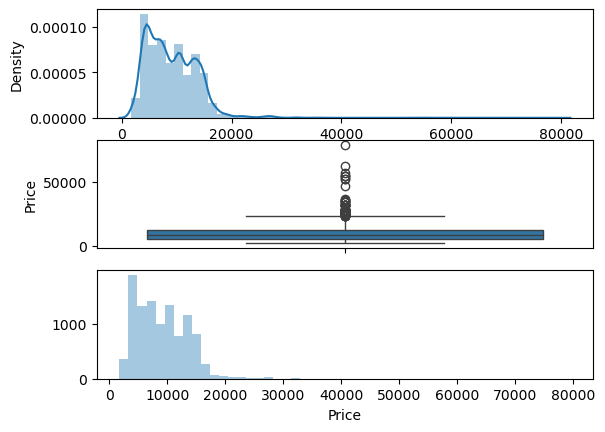

In [170]:
plot(data ,'Price')

In [175]:
q1= data['Price'].quantile(0.25)
q3= data['Price'].quantile(0.75)

iqr = q3- q1

maximum = q3 + 1.5*iqr
minimum = q1 - 1.5*iqr

In [176]:
print(maximum)

23017.0


In [177]:
print(minimum)

-5367.0


In [178]:
print([price for price in data ['Price'] if price> maximum or price< minimum])

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [ ]:
# to find the outlier call out the len function

In [179]:
len([price for price in data ['Price'] if price> maximum or price< minimum])

94

In [ ]:
# replace all outlier with median of the price leveraging the whwere function

In [180]:
data['Price'] = np.where(data['Price']>=35000 , data['Price'].median() ,data['Price'])

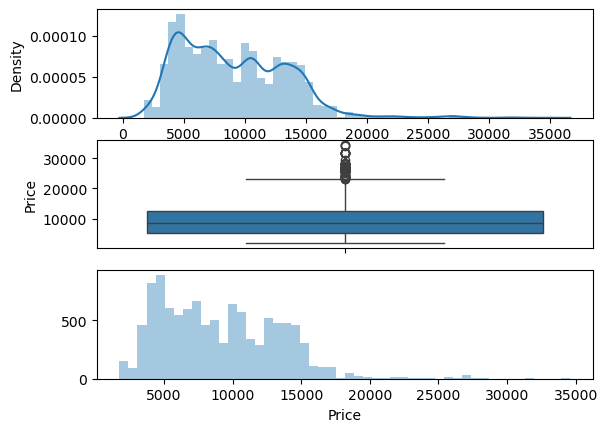

In [181]:
plot(data , 'Price')

In [ ]:
#performing feature engineering/ feature selection: trying to select best features which will contribute to my target variable

In [ ]:
#using mutual information approach


In [185]:
x = data.drop(['Price'] , axis=1)

In [186]:
y = data['Price']

In [ ]:
#importing mutual info regression 

In [187]:
from sklearn.feature_selection import mutual_info_regression

In [188]:
imp = mutual_info_regression(x ,y)

In [189]:
imp

array([1.32284321, 1.06180362, 0.7884566 , 0.62804122, 0.37239411,
       0.92074642, 0.75847134, 1.13909707, 0.9031619 , 1.12504283,
       0.67652061, 0.38047816, 0.45032945, 0.52219711, 0.12022958,
       0.19308734])

In [192]:
imp_df = pd.DataFrame(imp , index=x.columns)

In [193]:
imp_df.columns = ['importance']

In [194]:
imp_df

,importance
Airline,1.322843
Destination,1.061804
Total_Stops,0.788457
Journey_month,0.628041
Journey_day,0.372394
Dep_Time_hour,0.920746
Dep_Time_minute,0.758471
Arrival_Time_hour,1.139097
Arrival_Time_minute,0.903162
Duration_hour,1.125043


In [195]:
imp_df.sort_values(by='importance' , ascending=False)

,importance
Airline,1.322843
Arrival_Time_hour,1.139097
Duration_hour,1.125043
Destination,1.061804
Dep_Time_hour,0.920746
Arrival_Time_minute,0.903162
Total_Stops,0.788457
Dep_Time_minute,0.758471
Duration_mins,0.676521
Journey_month,0.628041


In [ ]:
#random forest is a machine lerning aglorithm :used in classification and regression and clustering

In [ ]:
#building a machine learning model and save the model.. we need a training data then testing data

In [196]:
from sklearn.model_selection import train_test_split

In [197]:
x_train, x_test, y_train, y_test = train_test_split(
   x, y, test_size=0.33, random_state=42)

In [ ]:
#building a random forest model

In [198]:
from sklearn.ensemble import RandomForestRegressor

In [200]:
ml_model = RandomForestRegressor()

In [201]:
ml_model.fit(x_train , y_train)

RandomForestRegressor()

In [202]:
y_pred = ml_model.predict(x_test)

In [203]:
y_pred

array([16742.7   ,  5301.81  ,  8996.35  , ...,  8131.44  ,  9040.76  ,
       11760.2425])

In [ ]:
#lets see how well the model is performin

In [204]:
from sklearn import metrics

In [205]:
metrics.r2_score(y_test , y_pred)

0.8166923848528241

In [ ]:
#saveing model / model dumping 

In [206]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [207]:
import pickle

In [209]:
file = open(r'C:\Users\test\Downloads\Flight_Price_resources/rf_random.pk1' , 'wb')

In [210]:
pickle.dump(ml_model , file)

In [211]:
model = open(r'C:\Users\test\Downloads\Flight_Price_resources/rf_random.pk1' , 'rb')

In [212]:
forest = pickle.load(model)

In [214]:
y_pred2 = forest.predict(x_test)

In [215]:
metrics.r2_score(y_test , y_pred2)

0.8166923848528241